--- Dataset Dimensions ---
Total records: 5572, Columns: 2

--- Class Counts ---
label
ham     4825
spam     747
Name: count, dtype: int64

================ EVALUATION SUMMARY ================
Multinomial Naive Bayes Accuracy: 97.22%
Logistic Regression Accuracy:     96.86%

--- Naive Bayes Classification Report ---
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



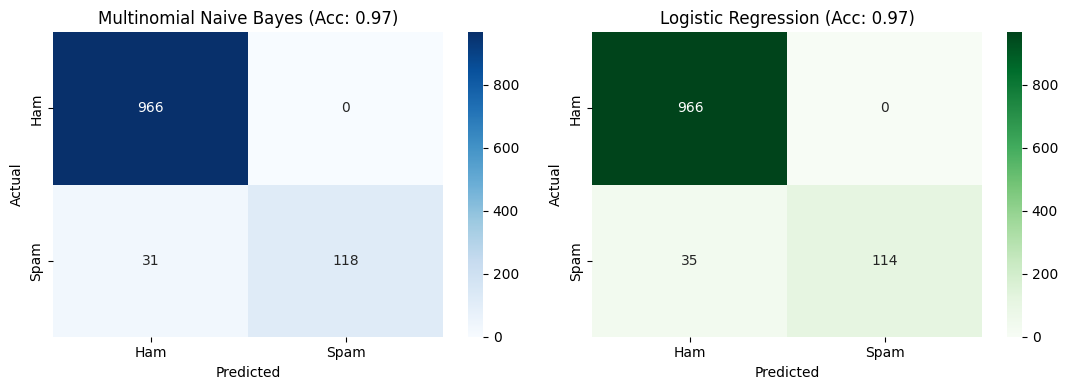


--- Live Test Predictions ---
[HAM (Legitimate)] -> Hey, are we still meeting up for project discussion at 5 PM today?
[SPAM] -> CONGRATULATIONS! You have been selected for a $1,000 cash prize. Click the link to claim immediately!


In [1]:
"""
Oasis Infobyte - Data Science Internship
Task 4: Email / SMS Spam Detection with Machine Learning
Author: Shivam Umesh Jaiswal
"""

import re
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Download & Load UCI SMS Spam Dataset
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "smsspamcollection.zip"
urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("spam_data")

df = pd.read_csv("spam_data/SMSSpamCollection", sep='\t', names=['label', 'message'])

print("--- Dataset Dimensions ---")
print(f"Total records: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n--- Class Counts ---")
print(df['label'].value_counts())

# 2. Text Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_message'] = df['message'].apply(clean_text)
df['target'] = df['label'].map({'ham': 0, 'spam': 1})

# 3. Train/Test Split & TF-IDF Vectorization
X = df['clean_message']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 4. Model Training
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
y_pred_nb = nb_model.predict(X_test_vec)

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_vec, y_train)
y_pred_lr = lr_model.predict(X_test_vec)

# 5. Model Evaluation
print("\n================ EVALUATION SUMMARY ================")
print(f"Multinomial Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb) * 100:.2f}%")
print(f"Logistic Regression Accuracy:     {accuracy_score(y_test, y_pred_lr) * 100:.2f}%\n")

print("--- Naive Bayes Classification Report ---")
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam']))

# 6. Confusion Matrix Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], ax=axes[0])
axes[0].set_title(f"Multinomial Naive Bayes (Acc: {accuracy_score(y_test, y_pred_nb):.2f})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], ax=axes[1])
axes[1].set_title(f"Logistic Regression (Acc: {accuracy_score(y_test, y_pred_lr):.2f})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# 7. Live Inference Test
sample_msgs = [
    "Hey, are we still meeting up for project discussion at 5 PM today?",
    "CONGRATULATIONS! You have been selected for a $1,000 cash prize. Click the link to claim immediately!"
]
sample_vecs = tfidf.transform([clean_text(m) for m in sample_msgs])
preds = nb_model.predict(sample_vecs)

print("\n--- Live Test Predictions ---")
for text, p in zip(sample_msgs, preds):
    label = "SPAM" if p == 1 else "HAM (Legitimate)"
    print(f"[{label}] -> {text}")